In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. PARAMETERS & SIGNAL GENERATION
# ==========================================
N = 150          # Total number of samples
D = 15           # Echo delay in samples
alpha = 0.5      # Echo amplitude (must be < 1 for stability)

# Create an original test signal x[n] (sparse pulses)
np.random.seed(0)
x = np.zeros(N)
x[10] = 1.0
x[40] = 0.7
x[80] = 0.9

# ==========================================
# 2. ECHO GENERATION
# ==========================================
# y[n] = x[n] + alpha * x[n - D]
y = np.zeros(N)
for n in range(N):
    delayed_sample = alpha * x[n - D] if (n - D) >= 0 else 0.0
    y[n] = x[n] + delayed_sample

# ==========================================
# 3. ECHO REMOVAL (INVERSE FILTERING)
# ==========================================
# x_rec[n] = y[n] - alpha * x_rec[n - D]
x_rec = np.zeros(N)
for n in range(N):
    delayed_rec = alpha * x_rec[n - D] if (n - D) >= 0 else 0.0
    x_rec[n] = y[n] - delayed_rec

# ==========================================
# 4. PLOTTING SIGNALS
# ==========================================
plt.figure(figsize=(10, 8))

plt.subplot(3, 1, 1)
plt.stem(x, basefmt="k-")
plt.title("1. Original Signal x[n]")
plt.ylabel("Amplitude")

plt.subplot(3, 1, 2)
plt.stem(y, basefmt="k-")
plt.title(f"2. Echoed Signal y[n] (alpha={alpha}, D={D})")
plt.ylabel("Amplitude")

plt.subplot(3, 1, 3)
plt.stem(x_rec, basefmt="k-")
plt.title("3. Recovered Signal x_rec[n]")
plt.xlabel("Sample Index [n]")
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

# ==========================================
# 5. ERROR INVESTIGATION (Varying Alpha & Delay)
# ==========================================
alphas = [0.1, 0.3, 0.5, 0.7, 0.9, 0.99]
errors = []

for a in alphas:
    # Simulate recovery for each alpha
    x_temp_rec = np.zeros(N)
    for n in range(N):
        prev = a * x_temp_rec[n - D] if (n - D) >= 0 else 0.0
        x_temp_rec[n] = y[n] - prev # using base y[n] with fixed D=15

    # Calculate Mean Squared Error (MSE)
    mse = np.mean((x - x_temp_rec) ** 2)
    errors.append(mse)

# Plot Error vs Alpha
plt.figure(figsize=(8, 4))
plt.plot(alphas, errors, marker='o', color='purple')
plt.title("Recovery Error (MSE) vs. Echo Amplitude (alpha)")
plt.xlabel("Alpha (alpha)")
plt.ylabel("Mean Squared Error")
plt.grid(True)
plt.show()

🔊 Original Simulated Speech:


🔊 Echoed Speech (Hear the overlapping syllables):


🔊 Recovered Speech (Clean and echo-free!):


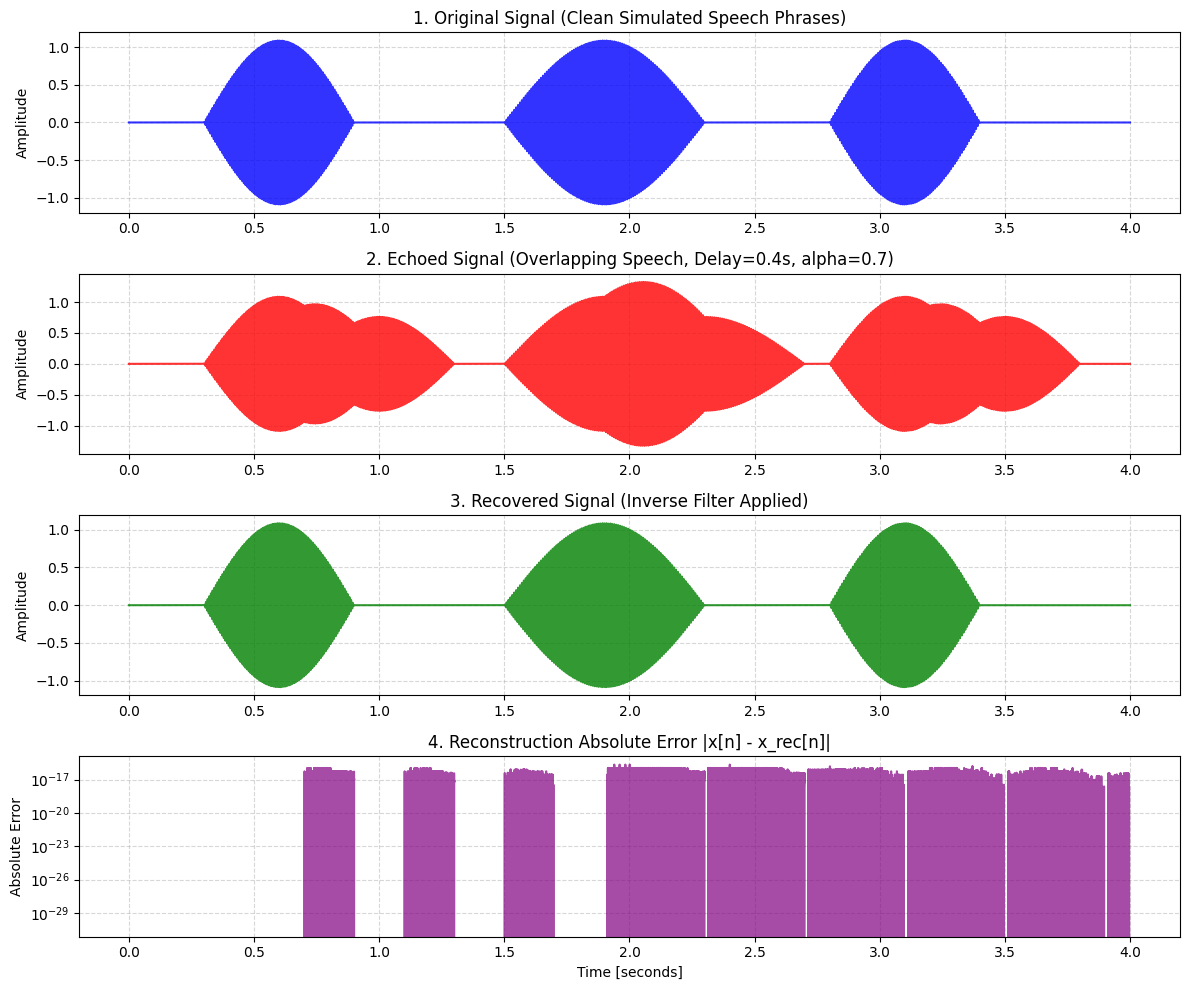

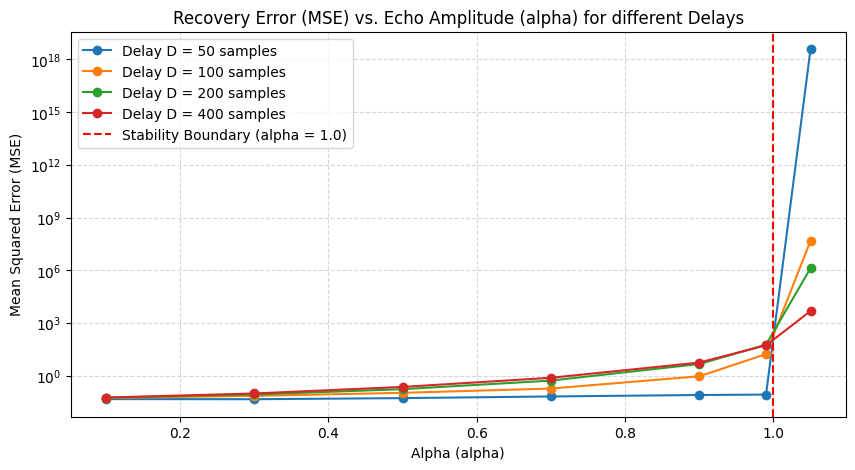

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display

# ==========================================
# 1. PARAMETERS & VOCAL AUDIO SYNTHESIS
# ==========================================
samplerate = 8000  # 8 kHz sample rate for clear speech simulation
duration = 4.0     # 4 seconds total duration
t = np.linspace(0, duration, int(samplerate * duration), endpoint=False)
N = len(t)

# Synthesize a speech-like signal with three main 'words' (pulses of complex tones)
# "good morning" at t=0.3s, "good afternoon" at t=1.5s, "good night" at t=2.8s
def generate_vocal_syllable(t_start, duration, fundamental_freq, amplitude):
    mask = (t >= t_start) & (t < t_start + duration)
    # Harmonic frequencies to mimic vocal cords (fundamental + formants)
    signal = (np.sin(2 * np.pi * fundamental_freq * t) +
              0.5 * np.sin(2 * np.pi * (2 * fundamental_freq) * t) +
              0.2 * np.sin(2 * np.pi * (3 * fundamental_freq) * t))
    # Smooth envelope for the word
    envelope = np.sin(np.pi * (t - t_start) / duration)
    return signal * envelope * mask * amplitude

x = np.zeros(N)
x += generate_vocal_syllable(0.3, 0.6, 150, 0.8)   # First phrase block
x += generate_vocal_syllable(1.5, 0.8, 130, 0.8)   # Second phrase block
x += generate_vocal_syllable(2.8, 0.6, 140, 0.8)   # Third phrase block

# ==========================================
# 2. ECHO GENERATION
# ==========================================
delay_seconds = 0.40  # 400 ms delay
D = int(delay_seconds * samplerate)
alpha = 0.7  # Strong audible echo

y = np.zeros(N)
for n in range(N):
    delayed_sample = alpha * x[n - D] if (n - D) >= 0 else 0.0
    y[n] = x[n] + delayed_sample

# ==========================================
# 3. ECHO REMOVAL (INVERSE FILTERING)
# ==========================================
x_rec = np.zeros(N)
for n in range(N):
    delayed_rec = alpha * x_rec[n - D] if (n - D) >= 0 else 0.0
    x_rec[n] = y[n] - delayed_rec

# ==========================================
# 4. AUDIO PLAYBACK & VISUALIZATION
# ==========================================
print("🔊 Original Simulated Speech:")
display(Audio(x, rate=samplerate))

print("🔊 Echoed Speech (Hear the overlapping syllables):")
display(Audio(y, rate=samplerate))

print("🔊 Recovered Speech (Clean and echo-free!):")
display(Audio(x_rec, rate=samplerate))

# Plot the comparative waveforms
plt.figure(figsize=(12, 10))

plt.subplot(4, 1, 1)
plt.plot(t, x, color='blue', alpha=0.8)
plt.title("1. Original Signal (Clean Simulated Speech Phrases)")
plt.ylabel("Amplitude")
plt.grid(True, linestyle='--', alpha=0.5)

plt.subplot(4, 1, 2)
plt.plot(t, y, color='red', alpha=0.8)
plt.title(f"2. Echoed Signal (Overlapping Speech, Delay={delay_seconds}s, alpha={alpha})")
plt.ylabel("Amplitude")
plt.grid(True, linestyle='--', alpha=0.5)

plt.subplot(4, 1, 3)
plt.plot(t, x_rec, color='green', alpha=0.8)
plt.title("3. Recovered Signal (Inverse Filter Applied)")
plt.ylabel("Amplitude")
plt.grid(True, linestyle='--', alpha=0.5)

# Add an Absolute Error Plot to show the precision of the recovery
plt.subplot(4, 1, 4)
plt.plot(t, np.abs(x - x_rec), color='purple', alpha=0.7)
plt.title("4. Reconstruction Absolute Error |x[n] - x_rec[n]|")
plt.xlabel("Time [seconds]")
plt.ylabel("Absolute Error")
plt.yscale('log')  # Log scale since numerical errors are near-zero
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# ==========================================
# 5. COMPREHENSIVE ERROR INVESTIGATION
# ==========================================
# Test error across a range of alphas and delays to investigate limits
test_alphas = [0.1, 0.3, 0.5, 0.7, 0.9, 0.99, 1.05]
test_delays = [50, 100, 200, 400]

plt.figure(figsize=(10, 5))
for d_val in test_delays:
    errors_by_delay = []
    for a_val in test_alphas:
        # Simulate reconstruction
        x_temp_rec = np.zeros(N)
        for n in range(N):
            prev = a_val * x_temp_rec[n - d_val] if (n - d_val) >= 0 else 0.0
            x_temp_rec[n] = y[n] - prev
        # Compute Mean Squared Error
        mse = np.mean((x - x_temp_rec) ** 2)
        errors_by_delay.append(mse)

    plt.plot(test_alphas, errors_by_delay, marker='o', label=f'Delay D = {d_val} samples')

plt.axvline(x=1.0, color='r', linestyle='--', label='Stability Boundary (alpha = 1.0)')
plt.title("Recovery Error (MSE) vs. Echo Amplitude (alpha) for different Delays")
plt.xlabel("Alpha (alpha)")
plt.ylabel("Mean Squared Error (MSE)")
plt.yscale('log')  # Logarithmic representation of errors
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()